Dataset Shape: (6803, 6)
             TimeStamp  Ventilador   PC   AC  Lampara   TV
0  12/29/2023 17:28:00      0.0270  0.0  0.0   0.0033  0.0
1  12/29/2023 17:29:00      0.0168  0.0  0.0   0.0000  0.0
2  12/29/2023 17:30:00      0.0210  0.0  0.0   0.0000  0.0
3  12/29/2023 17:31:00      0.0241  0.0  0.0   0.0000  0.0
4  12/29/2023 17:32:00      0.0218  0.0  0.0   0.0000  0.0


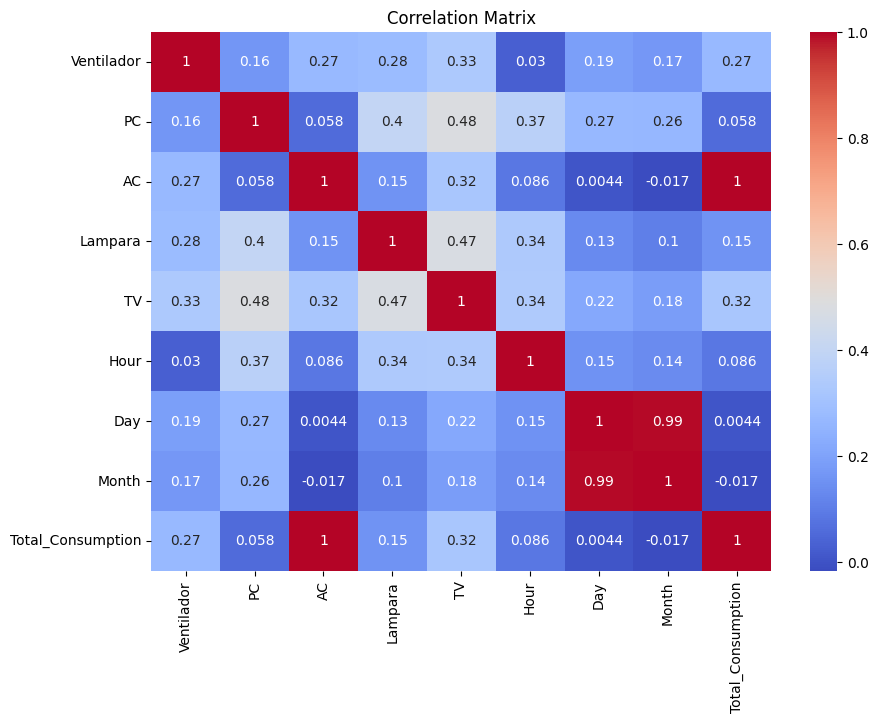

   Hour  avg_consumption  variance  peak_consumption
0     0         0.383550  0.178414            1.0691
1     1         0.444581  0.188110            1.0604
2     2         0.385722  0.175684            1.0595
3     3         0.370236  0.167850            1.0541
4     4         0.360158  0.162737            1.0563
    Hour  avg_consumption      variance  peak_consumption  Cluster
0      0         0.383550  1.784140e-01            1.0691        2
1      1         0.444581  1.881095e-01            1.0604        2
2      2         0.385722  1.756840e-01            1.0595        2
3      3         0.370236  1.678500e-01            1.0541        2
4      4         0.360158  1.627372e-01            1.0563        2
5      5         0.344929  1.543446e-01            1.0672        2
6      6        33.691450  3.333154e+05        10000.0874        0
7      7        33.663856  3.335245e+05        10003.1855        0
8      8       200.991436  1.977405e+06        10055.1605        0
9      9    

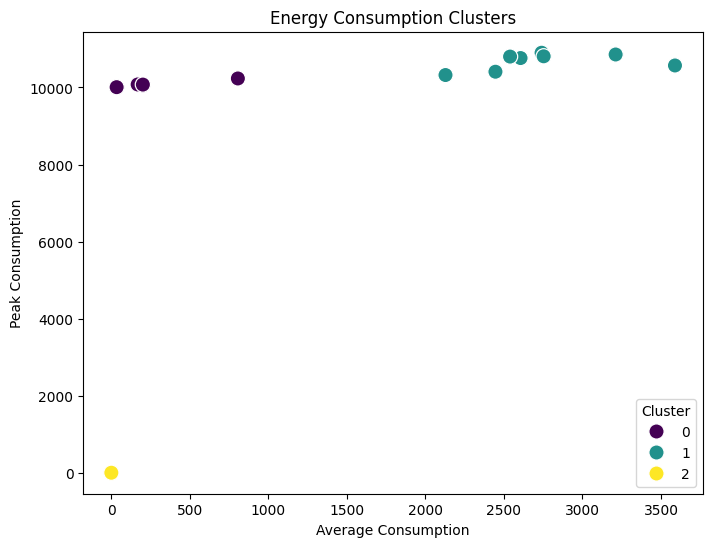


Random Forest Performance
RMSE: 0.9421107464728914
MAE: 0.14551984821757594
R² Score: 0.9999998960783486

Gradient Boosting Performance
RMSE: 1.076538602405606
MAE: 0.26104675468463784
R² Score: 0.9999998643057831

F Score Analysis
      Feature       F_score        p_value
0  Ventilador  5.328649e+02  1.423501e-113
1          PC  2.318335e+01   1.504503e-06
2          AC  1.649101e+13   0.000000e+00
3     Lampara  1.661911e+02   1.381078e-37
4          TV  7.772352e+02  4.699422e-162
5        Hour  5.060323e+01   1.246174e-12


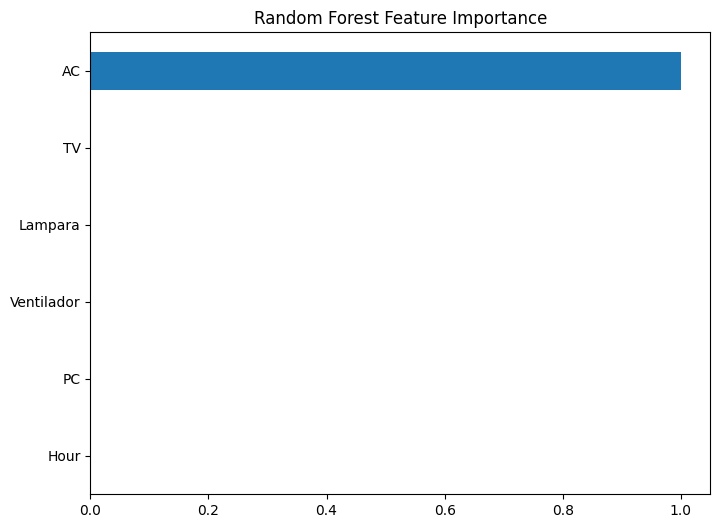

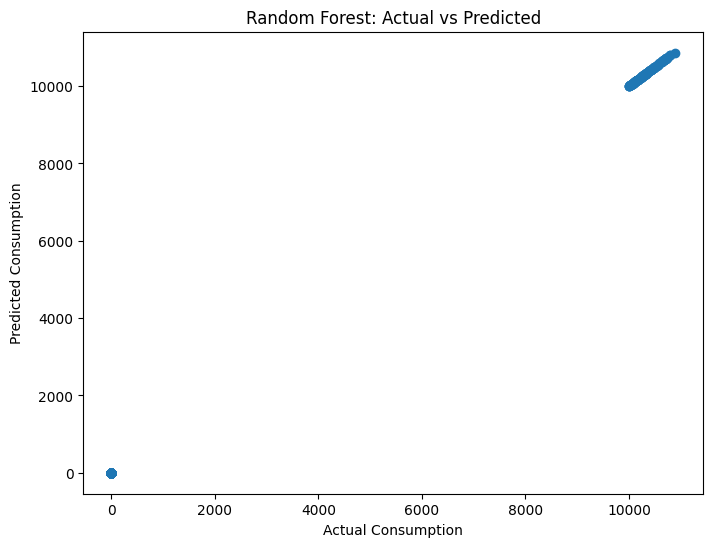


Cluster Consumption Patterns
              Hour  avg_consumption      variance  peak_consumption
Cluster                                                            
0        12.428571       211.039999  2.013692e+06      10064.303057
1        13.500000      2751.370213  2.095118e+07      10678.673787
2         9.000000         0.428063  1.830479e-01          1.106178


In [5]:
# =========================================
# ENERGY CONSUMPTION FORECASTING PIPELINE
# =========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.feature_selection import f_regression

# =========================================
# Load Dataset (already uploaded to Colab)
# =========================================

df = pd.read_excel("Energy Consumption Dataset For Smart Homes.xlsx")

print("Dataset Shape:", df.shape)
print(df.head())

# =========================================
# Data Preprocessing
# =========================================

df.columns = df.columns.str.strip()

df['TimeStamp'] = pd.to_datetime(df['TimeStamp'])

df['Hour'] = df['TimeStamp'].dt.hour
df['Day'] = df['TimeStamp'].dt.day
df['Month'] = df['TimeStamp'].dt.month

# Total consumption
df['Total_Consumption'] = df[['Ventilador','PC','AC','Lampara','TV']].sum(axis=1)

# =========================================
# Correlation Matrix
# =========================================

plt.figure(figsize=(10,7))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# =========================================
# Feature Extraction
# =========================================

features = df.groupby('Hour')['Total_Consumption'].agg(
    avg_consumption='mean',
    variance='var',
    peak_consumption='max'
).reset_index()

features = features.fillna(0)

print(features.head())

# =========================================
# Clustering
# =========================================

scaler = StandardScaler()

X_cluster = scaler.fit_transform(
    features[['avg_consumption','variance','peak_consumption']]
)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

features['Cluster'] = kmeans.fit_predict(X_cluster)

print(features)

# =========================================
# Cluster Visualization
# =========================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=features['avg_consumption'],
    y=features['peak_consumption'],
    hue=features['Cluster'],
    palette='viridis',
    s=120
)

plt.title("Energy Consumption Clusters")
plt.xlabel("Average Consumption")
plt.ylabel("Peak Consumption")

plt.show()

# =========================================
# Prepare Data for Prediction
# =========================================

X = df[['Ventilador','PC','AC','Lampara','TV','Hour']]
y = df['Total_Consumption']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================================
# Random Forest Model
# =========================================

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

# =========================================
# Gradient Boosting Model
# =========================================

gb = GradientBoostingRegressor()

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

# =========================================
# Model Evaluation
# =========================================

def evaluate_model(y_true, y_pred):

    rmse = np.sqrt(mean_squared_error(y_true,y_pred))
    mae = mean_absolute_error(y_true,y_pred)
    r2 = r2_score(y_true,y_pred)

    print("RMSE:", rmse)
    print("MAE:", mae)
    print("R² Score:", r2)

print("\nRandom Forest Performance")
evaluate_model(y_test, rf_pred)

print("\nGradient Boosting Performance")
evaluate_model(y_test, gb_pred)

# =========================================
# F Score Feature Importance
# =========================================

f_scores, p_values = f_regression(X, y)

fscore_df = pd.DataFrame({
    "Feature": X.columns,
    "F_score": f_scores,
    "p_value": p_values
})

print("\nF Score Analysis")
print(fscore_df)

# =========================================
# Random Forest Feature Importance
# =========================================

importance = pd.Series(rf.feature_importances_, index=X.columns)

importance.sort_values().plot(kind='barh', figsize=(8,6))

plt.title("Random Forest Feature Importance")

plt.show()

# =========================================
# Prediction vs Actual
# =========================================

plt.figure(figsize=(8,6))

plt.scatter(y_test, rf_pred)

plt.xlabel("Actual Consumption")
plt.ylabel("Predicted Consumption")

plt.title("Random Forest: Actual vs Predicted")

plt.show()

# =========================================
# Cluster Consumption Analysis
# =========================================

cluster_analysis = features.groupby('Cluster').mean()

print("\nCluster Consumption Patterns")
print(cluster_analysis)